In [10]:
!pip uninstall -y xgboost scikit-learn imbalanced-learn
!pip install --upgrade xgboost scikit-learn==1.3.0 imbalanced-learn

Found existing installation: xgboost 2.1.3
Uninstalling xgboost-2.1.3:
  Successfully uninstalled xgboost-2.1.3
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: imbalanced-learn 0.13.0
Uninstalling imbalanced-learn-0.13.0:
  Successfully uninstalled imbalanced-learn-0.13.0
INFO: pip is looking at multiple versions of imbalanced-learn to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but yo

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset (assuming the CSV file is in your Google Drive)
file_path = '/content/drive/MyDrive/EyeCareAI/vision_theme_dataset.csv'
df = pd.read_csv(file_path)


# Display first few rows
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Gender,Color Blind,Short-Sighted,Distance Vision,Near Vision,Color Discrimination,Label
0,Under 18,Male,0,0,5,5,0,0
1,Under 18,Male,0,0,5,5,1,0
2,Under 18,Male,0,0,5,10,0,0
3,Under 18,Male,0,0,5,10,1,0
4,Under 18,Male,0,0,5,15,0,0


In [3]:
# Encode categorical variables
label_encoders = {}
categorical_cols = ["Age", "Gender"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoder for future decoding

# Display updated data
df.head()


,Age,Gender,Color Blind,Short-Sighted,Distance Vision,Near Vision,Color Discrimination,Label
0,3,1,0,0,5,5,0,0
1,3,1,0,0,5,5,1,0
2,3,1,0,0,5,10,0,0
3,3,1,0,0,5,10,1,0
4,3,1,0,0,5,15,0,0


In [4]:
# Separate features and target variable
X = df.drop(columns=["Label"])
y = df["Label"]


In [5]:
# Normalize numerical features
scaler = StandardScaler()
X[["Distance Vision", "Near Vision"]] = scaler.fit_transform(X[["Distance Vision", "Near Vision"]])


In [6]:
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Print class distribution after balancing
print("Class distribution after SMOTE balancing:")
print(pd.Series(y_resampled).value_counts())


Class distribution after SMOTE balancing:
Label
0    25231
5    25231
4    25231
3    25231
2    25231
1    25231
7    25231
6    25231
Name: count, dtype: int64


In [7]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [8]:
# Train the XGBoost model
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [9]:
# Make predictions
y_pred = model.predict(X_test)

# Model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5093
           1       1.00      1.00      1.00      5078
           2       1.00      1.00      1.00      5011
           3       1.00      1.00      1.00      5036
           4       1.00      1.00      1.00      5023
           5       1.00      1.00      1.00      5103
           6       1.00      1.00      1.00      5070
           7       1.00      1.00      1.00      4956

    accuracy                           1.00     40370
   macro avg       1.00      1.00      1.00     40370
weighted avg       1.00      1.00      1.00     40370



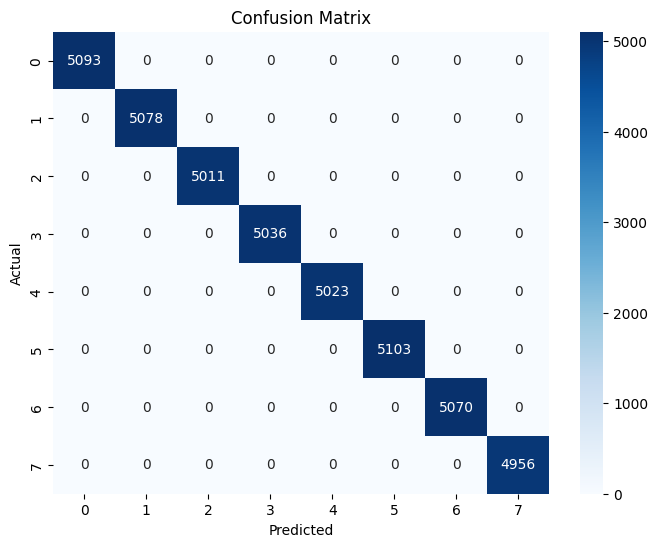

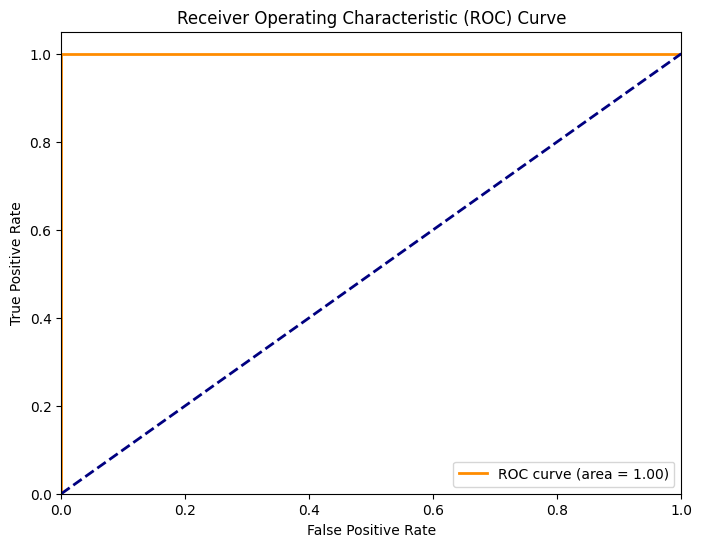

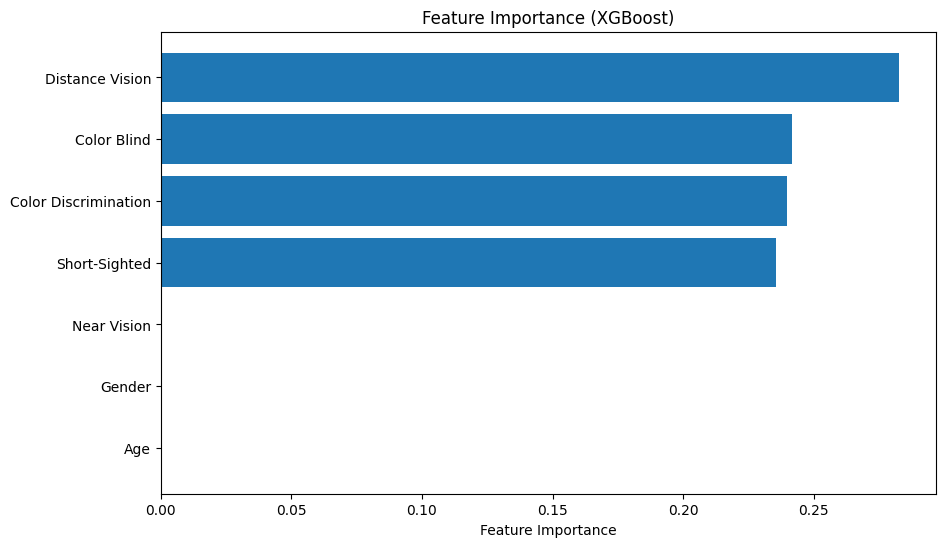

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix Plot
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Feature Importance (for tree-based models like XGBoost)
if hasattr(model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    feature_importance = model.feature_importances_
    feature_names = X_test.columns
    sorted_idx = feature_importance.argsort()
    plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
    plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
    plt.xlabel('Feature Importance')
    plt.title('Feature Importance (XGBoost)')
    plt.show()


In [11]:
joblib.dump(label_encoders, '/content/drive/MyDrive/EyeCareAI/label_encoders.pkl')
joblib.dump(model, '/content/drive/MyDrive/EyeCareAI/vision_theme_recommendation_model.pkl')


['/content/drive/MyDrive/EyeCareAI/vision_theme_recommendation_model.pkl']

In [12]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

# Load the saved model and label encoders
model = joblib.load('/content/drive/MyDrive/EyeCareAI/vision_theme_recommendation_model.pkl')
label_encoders = joblib.load('/content/drive/MyDrive/EyeCareAI/label_encoders.pkl')

# Test data
test_data = pd.DataFrame({
    "Age": ["Under 18", "51+", "18-30", "Under 18"],
    "Gender": ["Male", "Male", "Female", "Male"],
    "Color Blind": [0, 1, 0, 1],
    "Short-Sighted": [0, 0, 0, 1],
    "Distance Vision": [5, 5, 20, 5],
    "Near Vision": [5, 20, 15, 5],
    "Color Discrimination": [0, 0, 1, 1]
})

# Encode categorical variables
for col in ["Age", "Gender"]:
    le = label_encoders[col]
    test_data[col] = le.transform(test_data[col])

# Normalize numerical features
scaler = StandardScaler()
test_data[["Distance Vision", "Near Vision"]] = scaler.fit_transform(test_data[["Distance Vision", "Near Vision"]])

# Predict using the trained model
predictions = model.predict(test_data)

# Print predictions
print("Predicted Labels for the Test Data:")
print(predictions)


Predicted Labels for the Test Data:
[0 2 0 6]
